In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from wordcloud import WordCloud
from matplotlib.patches import Rectangle

In [2]:
plt.rcParams.update({"font.family": "serif"})
plt.rcParams.update({"figure.dpi": 100}) #100 or 300

# Init

In [ ]:
df = pd.read_excel('SLR.xlsx',sheet_name="review_final")
df.drop(42,inplace=True)
df.drop(43,inplace=True)
df['Publication Year'] = df['Publication Year'].astype(int)
df

,Include,notes_screening1,Notes,Citationkey,Author,Title,Publication Year,method_automated_measurement,method_visualization,method_automated_generation,...,measurement_speech,measurement_walking_speed,measurement_gaze,measurement_pupil,measurement_body_tracking,measurement_movement,measurement_respiration,measurement_pressure_load,control_measurement,control_dimension
0,include,Usability Evaluation nachlesen,Ergonomics as usability factor in AR,andronasSeamlessCollaborationHumans2023,"Andronas, Dionisis; Kampourakis, Emmanouil; Pa...",Towards seamless collaboration of humans and h...,2023,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,x,1.0,1.0
1,include,agent based,technique proposal UX test agents als phd topic,sabagholizadehansariAutomatedAssessmentUser2020,"Ansari, Saba Gholizadeh",Toward Automated Assessment of User Experience...,2020,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0
2,include,physiological factors,flow,bianFrameworkPhysiologicalIndicators2016,"Bian, Yulong; Yang, Chenglei; Gao, Fengqiang; ...",A framework for physiological indicators of fl...,2016,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,x,NaN,3.0,1.0
3,include,Movement,sehr kleine study und nur plot vom movement ke...,biriczUserFriendlyVirtual2022,"Biricz, Bence; Jónás, Viktor; Vincze, Miklós; ...",User friendly virtual reality software develop...,2022,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0
4,include,physiological factors,EEG,bozgeyikliExploringHorizontallyFlipped2023,"Bozgeyikli, Lal Lila; Bozgeyikli, Evren; Schne...",Exploring Horizontally Flipped Interaction in ...,2023,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0
5,include,Automatisierung nachlesen,ausführliches paper über fr nfr von locomotion,cannavoEvaluationTestbedLocomotion2021,"Cannavo, Alberto; Calandra, Davide; Prattico, ...",An Evaluation Testbed for Locomotion in Virtua...,2021,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
6,include,Event-based,Correlation of events to heart beat,cheEventBasedUserExperience2019,"Che, Xiaoping; Ma, Siqi; Yu, Qi; Yue, Chenfeng",An Event-Based User Experience Evaluation Meth...,2019,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
7,include,Usability Evaluation nachlesen,nicht Usability aber User experience durch den...,dickinsonVirtualRealityCrowd2019,"Dickinson, Patrick; Gerling, Kathrin; Hicks, K...",Virtual reality crowd simulation: effects of a...,2019,x,x,NaN,...,NaN,NaN,NaN,NaN,NaN,x,NaN,NaN,1.0,1.0
8,include,physiological factors,heart beat,dollingerIfItsNot2023,"Döllinger, Nina; Beck, Matthias; Wolf, Erik; M...",“If It’s Not Me It Doesn’t Make a Difference” ...,2023,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
9,include,eye tracking,NaN,dzardanovaExploringImpactNonverbal2024,"Dzardanova, E.; Nikolakopoulou, V.; Kasapakis,...",Exploring the impact of non-verbal cues on use...,2024,x,NaN,NaN,...,NaN,NaN,x,NaN,NaN,NaN,NaN,NaN,3.0,3.0


In [4]:
df.columns

Index(['Include', 'notes_screening1', 'Notes', 'Citationkey', 'Author',
       'Title', 'Publication Year', 'method_automated_measurement',
       'method_visualization', 'method_automated_generation', 'method_agent',
       'method_AutoQUEST', 'method_machine_learning', 'methodology',
       'Usability dimension', 'Baseline', 'Sample Size', 'Notes.1',
       'XR Technology', 'Measurement', 'dimension_general_usability',
       'dimension_generalUX', 'dimension_presence', 'dimension_flow',
       'dimension_interactability', 'dimension_learnability',
       'dimension_emotions', 'dimension_usability_smells', 'dimension_stress',
       'dimension_anxiety', 'dimension_ease_of_use', 'dimension_attention',
       'dimension_UI', 'dimension_behaviour', 'dimension_comfort',
       'dimension_cognitive_load', 'dimension_engagement',
       'dimension_area_of_interest', 'dimension_realism',
       'dimension_sentiment', 'dimension_physiological_arousal',
       'dimension_physical_effort', 'me

In [5]:
df = df.replace("NaN", np.nan)

binary_cols = df.filter(regex="^(dimension_|measurement_|method_)").columns
df[binary_cols] = df[binary_cols].eq("x").astype(int)

In [6]:
df.head()

,Include,notes_screening1,Notes,Citationkey,Author,Title,Publication Year,method_automated_measurement,method_visualization,method_automated_generation,...,measurement_speech,measurement_walking_speed,measurement_gaze,measurement_pupil,measurement_body_tracking,measurement_movement,measurement_respiration,measurement_pressure_load,control_measurement,control_dimension
0,include,Usability Evaluation nachlesen,Ergonomics as usability factor in AR,andronasSeamlessCollaborationHumans2023,"Andronas, Dionisis; Kampourakis, Emmanouil; Pa...",Towards seamless collaboration of humans and h...,2023,1,0,0,...,0,0,0,0,0,0,0,1,1.0,1.0
1,include,agent based,technique proposal UX test agents als phd topic,sabagholizadehansariAutomatedAssessmentUser2020,"Ansari, Saba Gholizadeh",Toward Automated Assessment of User Experience...,2020,0,0,0,...,0,0,0,0,0,0,0,0,1.0,2.0
2,include,physiological factors,flow,bianFrameworkPhysiologicalIndicators2016,"Bian, Yulong; Yang, Chenglei; Gao, Fengqiang; ...",A framework for physiological indicators of fl...,2016,1,0,0,...,0,0,0,0,0,0,1,0,3.0,1.0
3,include,Movement,sehr kleine study und nur plot vom movement ke...,biriczUserFriendlyVirtual2022,"Biricz, Bence; Jónás, Viktor; Vincze, Miklós; ...",User friendly virtual reality software develop...,2022,1,0,0,...,0,0,0,0,0,0,0,0,2.0,2.0
4,include,physiological factors,EEG,bozgeyikliExploringHorizontallyFlipped2023,"Bozgeyikli, Lal Lila; Bozgeyikli, Evren; Schne...",Exploring Horizontally Flipped Interaction in ...,2023,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2.0


# Metadata

<Axes: xlabel='Publication Year'>

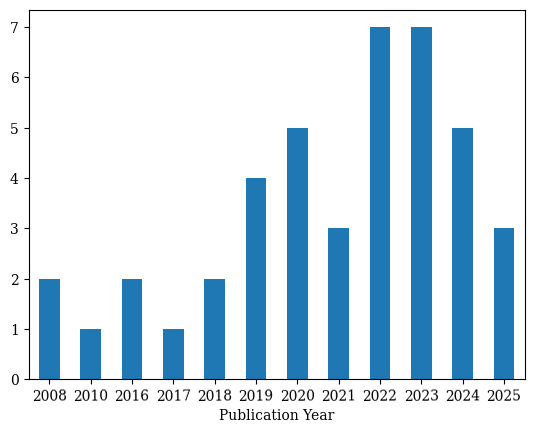

In [7]:
df.groupby(['Publication Year']).size().plot.bar(rot=1)

In [8]:
df.groupby(['XR Technology']).size()

,0
XR Technology,
AR,10
"AR, VR",1
MR,2
VR,27
XR,2


<Axes: xlabel='XR Technology'>

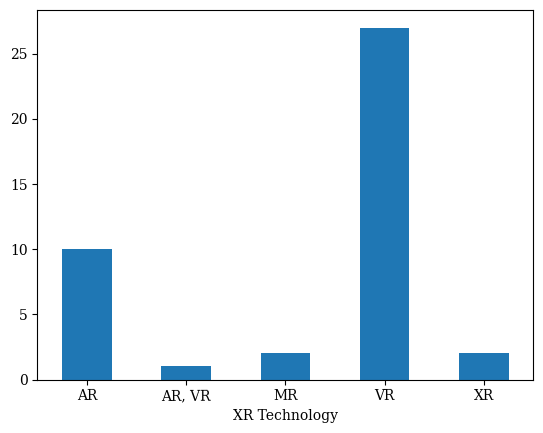

In [9]:
df.groupby(['XR Technology']).size().plot.bar(rot=0.25)

{'VR': np.int64(28), 'AR': np.int64(11), 'XR': np.int64(2), 'MR': np.int64(2)}


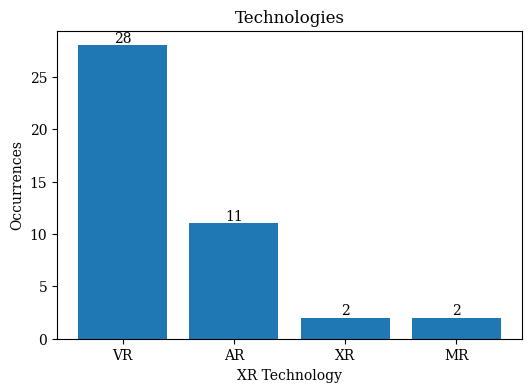

In [10]:
vr_count = df['XR Technology'].str.contains('VR', na=False).sum()
ar_count = df['XR Technology'].str.contains('AR', na=False).sum()
xr_count = df['XR Technology'].str.contains('XR', na=False).sum()
mr_count = df['XR Technology'].str.contains('MR', na=False).sum()
xr_counts = {'VR': vr_count, 'AR': ar_count, 'XR': xr_count, 'MR': mr_count}
print(xr_counts)

plt.figure(figsize=(6, 4))
plt.bar(xr_counts.keys(), xr_counts.values())
plt.bar_label(plt.gca().containers[0])
plt.title("Technologies")
plt.ylabel("Occurrences")
plt.xlabel("XR Technology")
plt.show()

# Collected Measurements

In [11]:
def clean_label(colname: str) -> str:
    colname = colname.replace("dimension_", "").replace("measurement_", "")
    colname = colname.replace("_", " ")
    colname = colname.replace("general", "")
    return colname.upper()

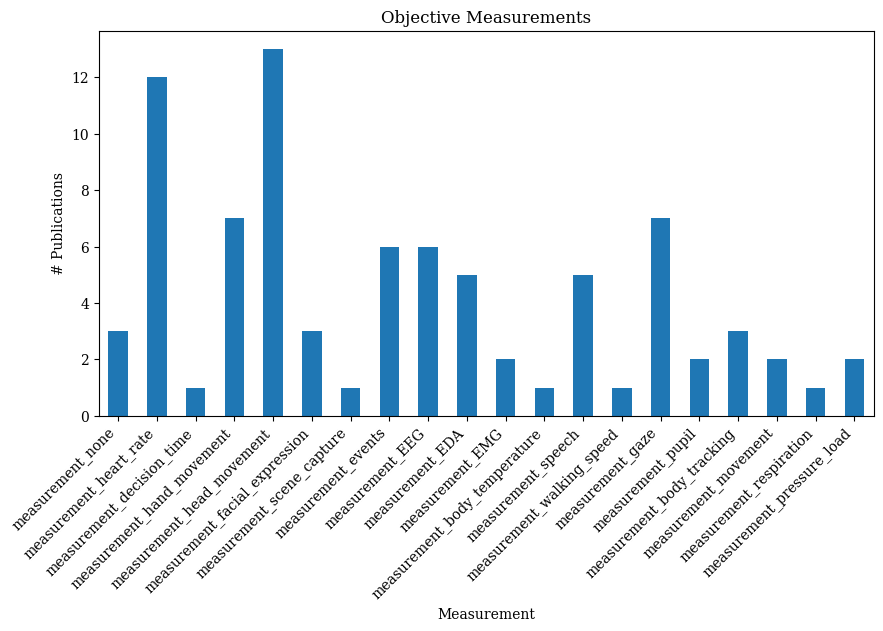

In [12]:
measurement_counts = df.filter(like="measurement_").sum()
plt.figure(figsize=(10, 5))
measurement_counts.plot(kind="bar")
plt.title("Objective Measurements")
plt.ylabel("# Publications")
plt.xlabel("Measurement")
plt.xticks(rotation=45, ha="right")
plt.show()

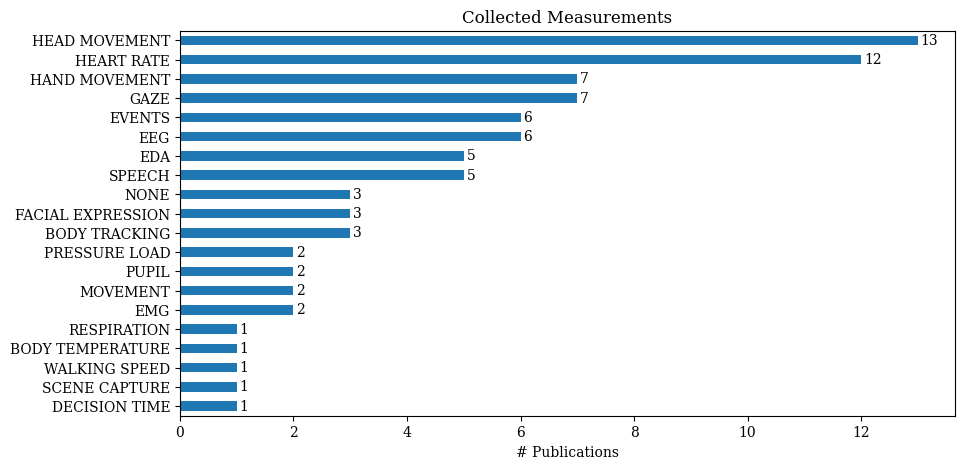

In [13]:
measurement_counts = df.filter(like="measurement_").sum().sort_values()

measurement_counts.index = [clean_label(col) for col in measurement_counts.index]

plt.figure(figsize=(10, 5))
measurement_counts.plot(kind="barh")
plt.title("Collected Measurements")
plt.xlabel("# Publications")
plt.bar_label(plt.gca().containers[0], padding=2)
plt.show()

# Collected Usability Dimensions

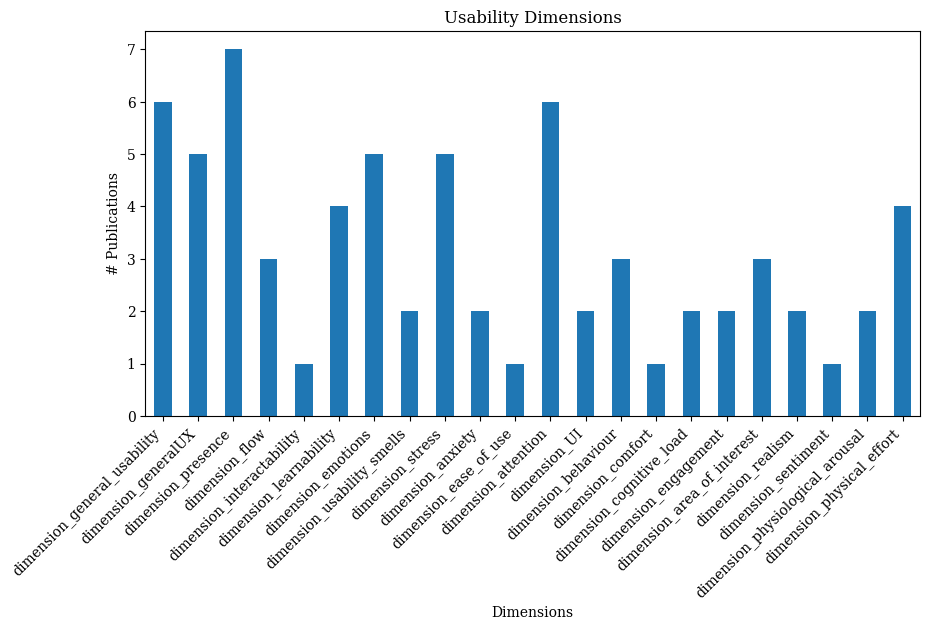

In [14]:
dimension_counts = df.filter(like="dimension_").sum()
plt.figure(figsize=(10, 5))
dimension_counts.plot(kind="bar")
plt.title("Usability Dimensions")
plt.ylabel("# Publications")
plt.xlabel("Dimensions")
plt.xticks(rotation=45, ha="right")
plt.show()

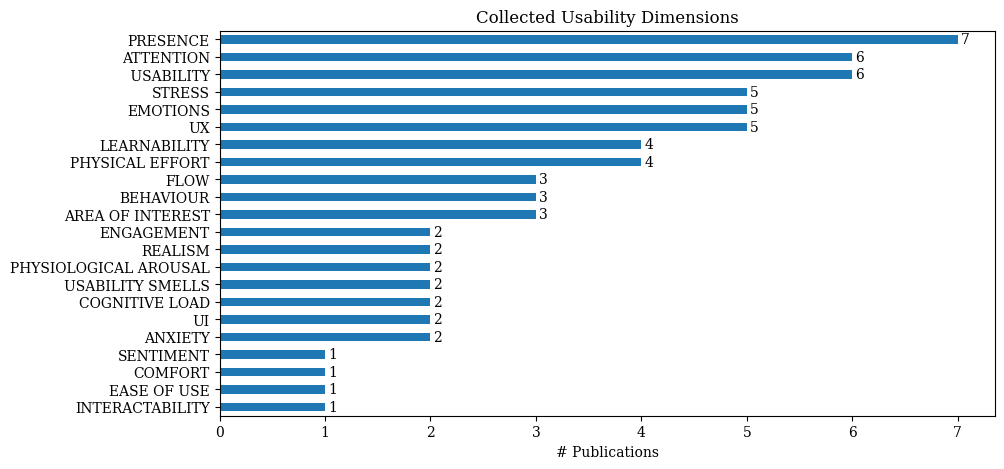

In [15]:
dimension_counts = df.filter(like="dimension_").sum().sort_values()

dimension_counts.index = [clean_label(col) for col in dimension_counts.index]

plt.figure(figsize=(10, 5))
dimension_counts.plot(kind="barh")
plt.title("Collected Usability Dimensions")
plt.xlabel("# Publications")
plt.bar_label(plt.gca().containers[0], padding=2)
plt.show()

# Analysis of Measurements

In [16]:
physiological = [
    "measurement_heart_rate", "measurement_EEG", "measurement_EDA",
    "measurement_EMG", "measurement_body_temperature",
    "measurement_respiration", "measurement_pupil"
]
phys_color = "tab:orange"

behavioral = [
    "measurement_decision_time", "measurement_hand_movement",
    "measurement_head_movement", "measurement_facial_expression",
    "measurement_speech", "measurement_walking_speed",
    "measurement_gaze", "measurement_body_tracking",
    "measurement_movement", "measurement_pressure_load",
    "measurement_events"
]
behav_color = "tab:blue"

other = [
    "measurement_none", "measurement_scene_capture"
]
other_color = "tab:gray"

df["has_physiological"] = (df[physiological].max(axis=1))
df["has_behavioral"] = (df[behavioral].max(axis=1))
df["has_other"] = (df[other].max(axis=1))

measurement_category_papers = {
    "Physiological": df["has_physiological"].sum(),
    "Behavioral": df["has_behavioral"].sum(),
    "Other": df["has_other"].sum()
}

measurement_category_papers

{'Physiological': np.int64(21),
 'Behavioral': np.int64(28),
 'Other': np.int64(4)}

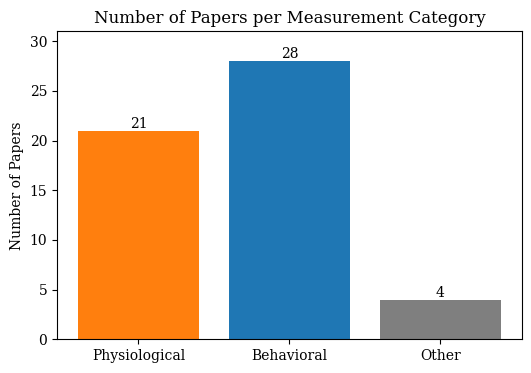

In [17]:
plt.figure(figsize=(6, 4))
plt.ylim(0, 31)
plt.bar(measurement_category_papers.keys(), measurement_category_papers.values(), color=[phys_color,behav_color,other_color])
plt.title("Number of Papers per Measurement Category")
plt.ylabel("Number of Papers")
plt.bar_label(plt.gca().containers[0])
plt.show()

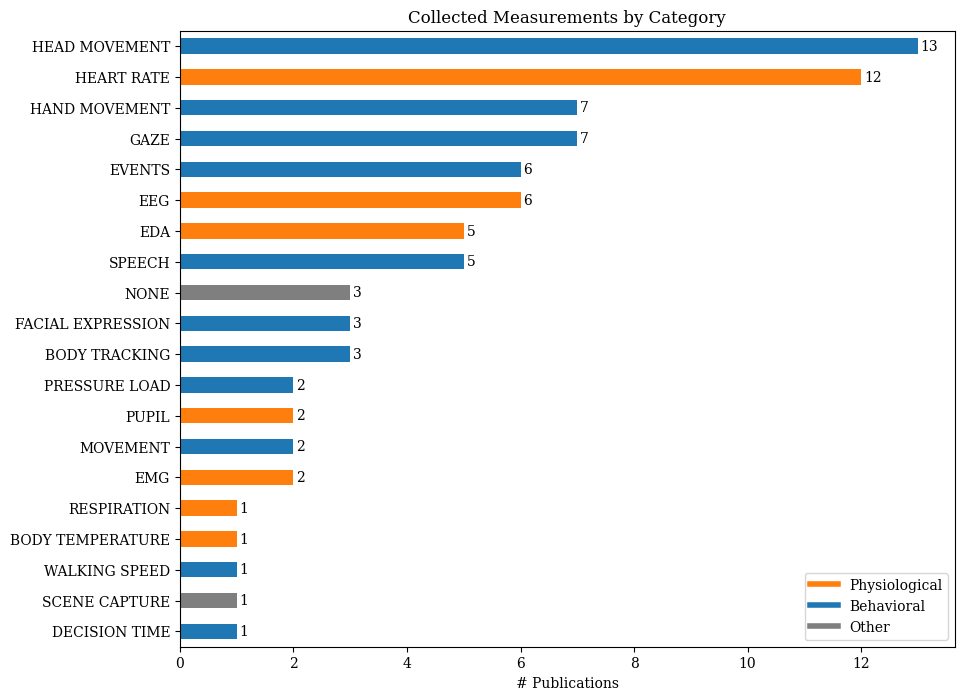

In [18]:
category_map = {}
for col in physiological: category_map[col] = phys_color
for col in behavioral: category_map[col] = behav_color
for col in other: category_map[col] = other_color

measurement_counts = df.filter(like="measurement_").sum().sort_values()

colors = [category_map.get(col, 'grey') for col in measurement_counts.index]

measurement_counts.index = [clean_label(col) for col in measurement_counts.index]


plt.figure(figsize=(10, 8))
measurement_counts.plot(kind="barh", color=colors)
plt.title("Collected Measurements by Category")
plt.xlabel("# Publications")
plt.bar_label(plt.gca().containers[0], padding=2)
legend_elements = [
    Line2D([0], [0], color=phys_color, lw=4, label='Physiological'),
    Line2D([0], [0], color=behav_color, lw=4, label='Behavioral'),
    Line2D([0], [0], color=other_color, lw=4, label='Other')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.show()

# Analysis of Methods

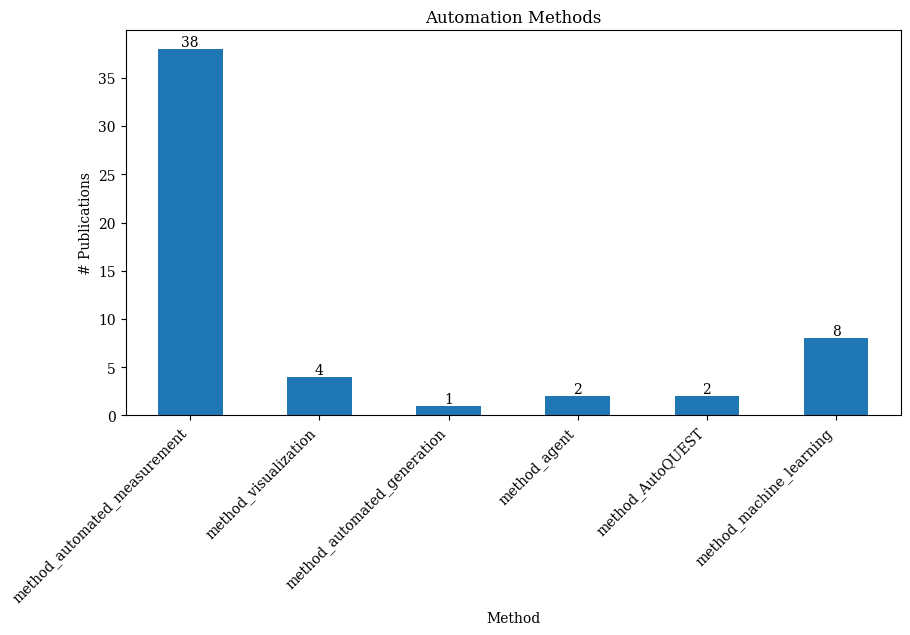

In [19]:
measurement_counts = df.filter(like="method_").sum()
plt.figure(figsize=(10, 5))
measurement_counts.plot(kind="bar")
plt.title("Automation Methods")
plt.ylabel("# Publications")
plt.xlabel("Method")
plt.bar_label(plt.gca().containers[0])
plt.xticks(rotation=45, ha="right")
plt.show()

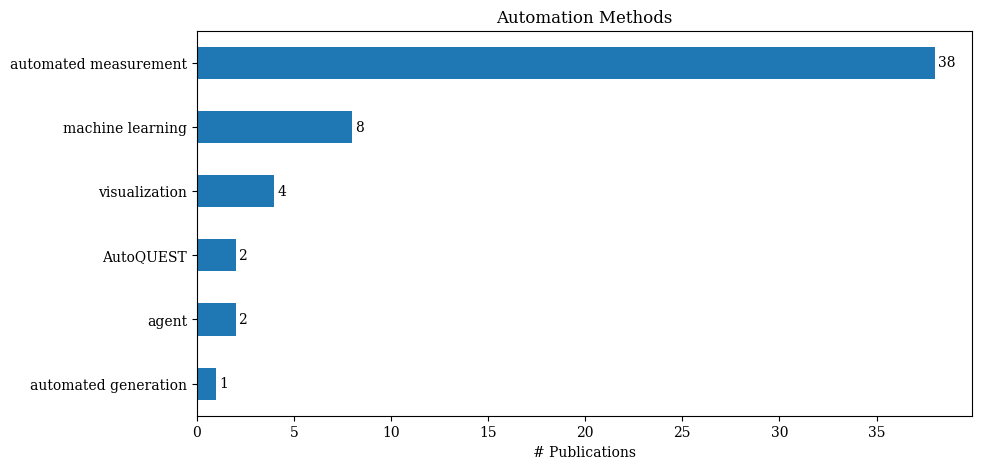

In [20]:
def clean_method_names(colname: str) -> str:
    colname = colname.replace("method_", "").replace("_", " ")
    return colname

method_counts = df.filter(like="method_").sum().sort_values()
method_counts.index = [clean_method_names(col) for col in method_counts.index]

plt.figure(figsize=(10, 5))
method_counts.plot(kind="barh")
plt.title("Automation Methods")
plt.xlabel("# Publications")
plt.bar_label(plt.gca().containers[0], padding=2)
plt.show()

In [21]:
method_cols= ['method_automated_measurement',
       'method_visualization', 'method_automated_generation', 'method_agent',
       'method_AutoQUEST', 'method_machine_learning']

In [22]:
# no other automation just capturing an manual evaluation
df["only_automated_measurement"] = (
    (df["method_automated_measurement"] == 1) &   # must have this
    (df[method_cols].sum(axis=1) == 1)            # and no others
)
df["only_automated_measurement"].sum()

np.int64(26)

In [23]:
# automated measurements and a form of automated evaluation
df["automated_evaluation_from_measurement"] = (
    (df["method_automated_measurement"] == 1) &
    (df[method_cols].sum(axis=1) > 1)
)
df["automated_evaluation_from_measurement"].sum()

np.int64(12)

In [24]:
# no automated measurements
df["no_automated_measurement"] = (df["method_automated_measurement"]==0)
df["no_automated_measurement"].sum()

np.int64(4)

In [25]:
df[df["no_automated_measurement"]]

,Include,notes_screening1,Notes,Citationkey,Author,Title,Publication Year,method_automated_measurement,method_visualization,method_automated_generation,...,measurement_respiration,measurement_pressure_load,control_measurement,control_dimension,has_physiological,has_behavioral,has_other,only_automated_measurement,automated_evaluation_from_measurement,no_automated_measurement
1,include,agent based,technique proposal UX test agents als phd topic,sabagholizadehansariAutomatedAssessmentUser2020,"Ansari, Saba Gholizadeh",Toward Automated Assessment of User Experience...,2020,0,0,0,...,0,0,1.0,2.0,0,0,1,False,False,True
30,include,agent based,"agent based, nur introduction",pradaAgentbasedTestingExtended2020,"Prada, Rui; Prasetya, I. S. W. B.; Kifetew, Fi...",Agent-based Testing of Extended Reality Systems,2020,0,0,0,...,0,0,1.0,3.0,0,0,1,False,False,True
31,include,Usability Evaluation nachlesen,"AR no usability, unrealistic object placement ...",rafiPredARTAutomaticOracle2023,"Rafi, Tahmid; Zhang, Xueling; Wang, Xiaoyin",PredART: Towards Automatic Oracle Prediction o...,2023,0,0,1,...,0,0,1.0,1.0,0,0,1,False,False,True
36,include,Automatisierung nachlesen,Viele Ideen und analysen auf ML basis aber kei...,sriRevolutionizingUserExperience2024,"Sri, Bande Bhavya; Amulya, Kadamati Dharani Na...",Revolutionizing User Experience for Product Qu...,2024,0,0,0,...,0,0,2.0,2.0,0,1,0,False,False,True


In [26]:
# no other automation just ML for usability with a dataset
df["only_machine_learning"] = (
    (df["method_machine_learning"] == 1) &
    (df[method_cols].sum(axis=1) == 1)
)
# df["only_machine_learning"].sum()
df[df["only_machine_learning"]]

,Include,notes_screening1,Notes,Citationkey,Author,Title,Publication Year,method_automated_measurement,method_visualization,method_automated_generation,...,measurement_pressure_load,control_measurement,control_dimension,has_physiological,has_behavioral,has_other,only_automated_measurement,automated_evaluation_from_measurement,no_automated_measurement,only_machine_learning
36,include,Automatisierung nachlesen,Viele Ideen und analysen auf ML basis aber kei...,sriRevolutionizingUserExperience2024,"Sri, Bande Bhavya; Amulya, Kadamati Dharani Na...",Revolutionizing User Experience for Product Qu...,2024,0,0,0,...,0,2.0,2.0,0,1,0,False,False,True,True


In [27]:
# machine learning approaches based on automated measurements
df["machine_learning_from_measures"] = (
    (df["method_machine_learning"] == 1) &
    (df["method_automated_measurement"] == 1)
)
# df["machine_learning_from_measures"].sum()
df[df["machine_learning_from_measures"]]

,Include,notes_screening1,Notes,Citationkey,Author,Title,Publication Year,method_automated_measurement,method_visualization,method_automated_generation,...,control_measurement,control_dimension,has_physiological,has_behavioral,has_other,only_automated_measurement,automated_evaluation_from_measurement,no_automated_measurement,only_machine_learning,machine_learning_from_measures
16,include,Usability Evaluation nachlesen,NaN,jamboVirtualRealitySystem2024,"Jambo, C.H.M.; Werneck, V.M.B.; Moreira da Cos...",Virtual Reality System Controlled by Embedded ...,2024,1,0,0,...,1.0,1.0,1,0,0,False,True,False,False,True
17,include,objective features,"Physiological and Movement measures, very good...",kaminskaUsabilityTestingVirtual2022,"Kamińska, D.; Zwoliński, G.; Laska-Leśniewicz, A.",Usability Testing of Virtual Reality Applicati...,2022,1,0,0,...,4.0,1.0,1,1,0,False,True,False,False,True
22,include,physiological factors,experimentalle Classification von Attention al...,longMultimodalDetectionExternal2024,"Long, Xingyu; Mayer, Sven; Chiossi, Francesco",Multimodal Detection of External and Internal ...,2024,1,0,0,...,2.0,1.0,1,0,0,False,True,False,False,True
24,include,Usability Evaluation nachlesen,multimodal ML Model trainiert auf presence,ochsMultimodalBehavioralCues2022,"Ochs, M.; Bousquet, J.; Pergandi, J.-M.; Blach...",Multimodal Behavioral Cues Analysis of the Sen...,2022,1,0,0,...,4.0,1.0,0,1,0,False,True,False,False,True
25,include,sentiment,Grundlage zu Multimodal Behavioral Cues Analys...,ochsAutomaticPredictionSense2018,"Ochs, M.; Jain, S.; Pergandi, J.-M.; Blache, P.",Toward an automatic prediction of the sense of...,2018,1,0,0,...,4.0,1.0,0,1,0,False,True,False,False,True
27,include,multimodal ux NN,multimodal deep nn,pannatteeDeepLearningFramework2025,"Pannattee, Peerawat; Shimada, Shogo; Yem, Vibo...",A deep learning framework for automatic assess...,2025,1,0,0,...,4.0,1.0,0,1,1,False,True,False,False,True


In [28]:
# machine learning approaches based on generated dataset
df["machine_learning_generation"] = (
    (df["method_machine_learning"] == 1) &
    (df["method_automated_generation"] == 1)
)
# df["machine_learning_generation"].sum()
df[df["machine_learning_generation"]]

,Include,notes_screening1,Notes,Citationkey,Author,Title,Publication Year,method_automated_measurement,method_visualization,method_automated_generation,...,control_dimension,has_physiological,has_behavioral,has_other,only_automated_measurement,automated_evaluation_from_measurement,no_automated_measurement,only_machine_learning,machine_learning_from_measures,machine_learning_generation
31,include,Usability Evaluation nachlesen,"AR no usability, unrealistic object placement ...",rafiPredARTAutomaticOracle2023,"Rafi, Tahmid; Zhang, Xueling; Wang, Xiaoyin",PredART: Towards Automatic Oracle Prediction o...,2023,0,0,1,...,1.0,0,0,1,False,False,True,False,False,True


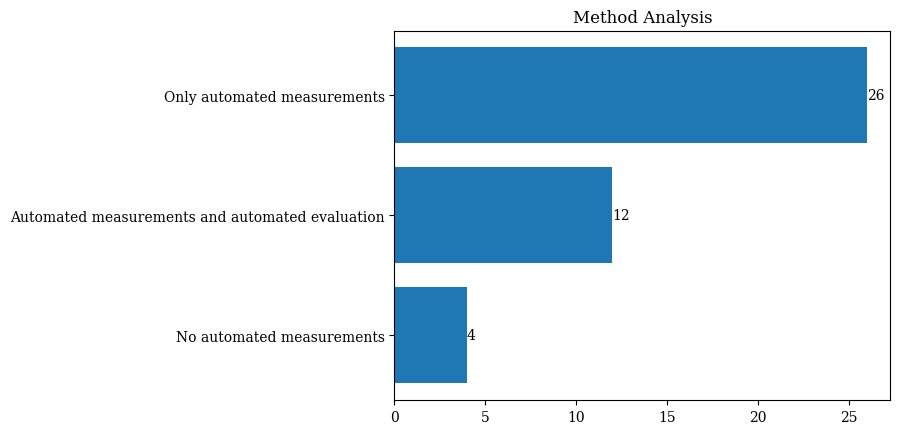

In [29]:
method_analysis = {
    "No automated measurements": df["no_automated_measurement"].sum(),
    "Automated measurements and automated evaluation": df["automated_evaluation_from_measurement"].sum(),
    "Only automated measurements": df["only_automated_measurement"].sum(),
}
plt.barh(method_analysis.keys(), method_analysis.values())
plt.bar_label(plt.gca().containers[0])
plt.title("Method Analysis")
plt.show()

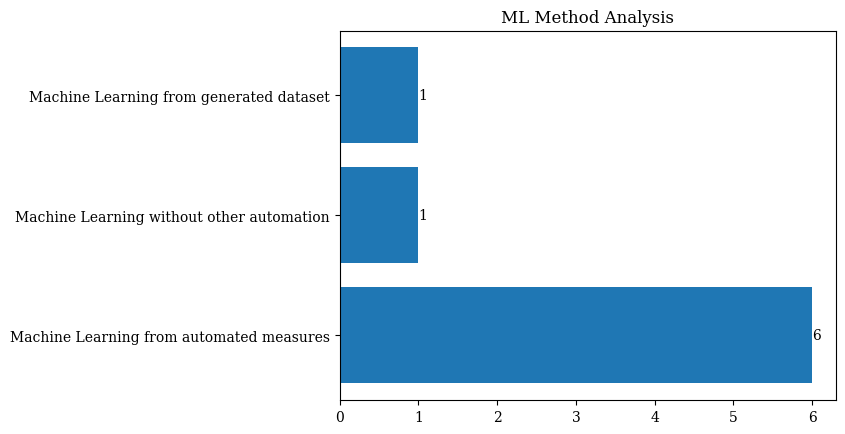

In [30]:
method_analysis = {
    "Machine Learning from automated measures": df["machine_learning_from_measures"].sum(),
    "Machine Learning without other automation": df["only_machine_learning"].sum(),
    "Machine Learning from generated dataset": df["machine_learning_generation"].sum(),
}
plt.barh(method_analysis.keys(), method_analysis.values())
plt.bar_label(plt.gca().containers[0])
plt.title("ML Method Analysis")
plt.show()

# Trade Off Matrix

In [31]:
# Ratings: 1=Low, 2=Moderate, 3=High
measurement_metadata_original = {
    # Physiological
    "measurement_heart_rate":      {"type": "Physiological", "cost": 1, "insight": 1},
    "measurement_EEG":             {"type": "Physiological", "cost": 3, "insight": 2},
    "measurement_EDA":             {"type": "Physiological", "cost": 2, "insight": 1},
    "measurement_pupil":           {"type": "Physiological", "cost": 3, "insight": 2},
    "measurement_EMG":             {"type": "Physiological", "cost": 3, "insight": 2},
    "measurement_respiration":     {"type": "Physiological", "cost": 2, "insight": 1},
    "measurement_body_temperature":{"type": "Physiological", "cost": 2, "insight": 1},
    # Behavioral
    "measurement_head_movement":   {"type": "Behavioral",    "cost": 1, "insight": 2},
    "measurement_hand_movement":   {"type": "Behavioral",    "cost": 1, "insight": 2},
    "measurement_gaze":            {"type": "Behavioral",    "cost": 3, "insight": 3},
    "measurement_events":          {"type": "Behavioral",    "cost": 2, "insight": 3},
    "measurement_speech":          {"type": "Behavioral",    "cost": 2, "insight": 2},
    "measurement_facial_expression":{"type": "Behavioral",   "cost": 3, "insight": 2},
    "measurement_body_tracking":   {"type": "Behavioral",    "cost": 3, "insight": 2},
    "measurement_pressure_load":   {"type": "Behavioral",    "cost": 3, "insight": 3},
    "measurement_movement":        {"type": "Behavioral",    "cost": 1, "insight": 2},
    "measurement_walking_speed":   {"type": "Behavioral",    "cost": 2, "insight": 1},
    "measurement_decision_time":   {"type": "Behavioral",    "cost": 2, "insight": 2},
    # Other
    # "measurement_none":            {"type": "Other",         "cost": 1, "insight": 1},
    "measurement_scene_capture":   {"type": "Other",         "cost": 1, "insight": 1},
}

measurement_metadata= {
    # Physiological
    "measurement_heart_rate":      {"type": "Physiological", "cost": 1.8, "insight": 1},
    "measurement_EEG":             {"type": "Physiological", "cost": 3, "insight": 2},
    "measurement_EDA":             {"type": "Physiological", "cost": 2.15, "insight": 1},
    "measurement_pupil":           {"type": "Physiological", "cost": 2.8, "insight": 2},
    "measurement_EMG":             {"type": "Physiological", "cost": 3, "insight": 2},
    "measurement_respiration":     {"type": "Physiological", "cost": 2, "insight": 1.2},
    "measurement_body_temperature":{"type": "Physiological", "cost": 1.975, "insight": 1.05},
    # Behavioral
    "measurement_head_movement":   {"type": "Behavioral",    "cost": 1, "insight": 2},
    "measurement_hand_movement":   {"type": "Behavioral",    "cost": 1, "insight": 2.2},
    "measurement_gaze":            {"type": "Behavioral",    "cost": 3, "insight": 3},
    "measurement_events":          {"type": "Behavioral",    "cost": 2, "insight": 3},
    "measurement_speech":          {"type": "Behavioral",    "cost": 2, "insight": 2},
    "measurement_facial_expression":{"type": "Behavioral",   "cost": 3, "insight": 2},
    "measurement_body_tracking":   {"type": "Behavioral",    "cost": 3, "insight": 2},
    "measurement_pressure_load":   {"type": "Behavioral",    "cost": 3, "insight": 3},
    "measurement_movement":        {"type": "Behavioral",    "cost": 1, "insight": 2},
    "measurement_walking_speed":   {"type": "Behavioral",    "cost": 2, "insight": 1},
    "measurement_decision_time":   {"type": "Behavioral",    "cost": 2, "insight": 2},
    # Other
    # "measurement_none":            {"type": "Other",         "cost": 1, "insight": 1},
    "measurement_scene_capture":   {"type": "Other",         "cost": 1, "insight": 1},
}

color_map = {
    "Physiological": "tab:orange",
    "Behavioral": "tab:blue",
    "Other": "tab:gray"
}

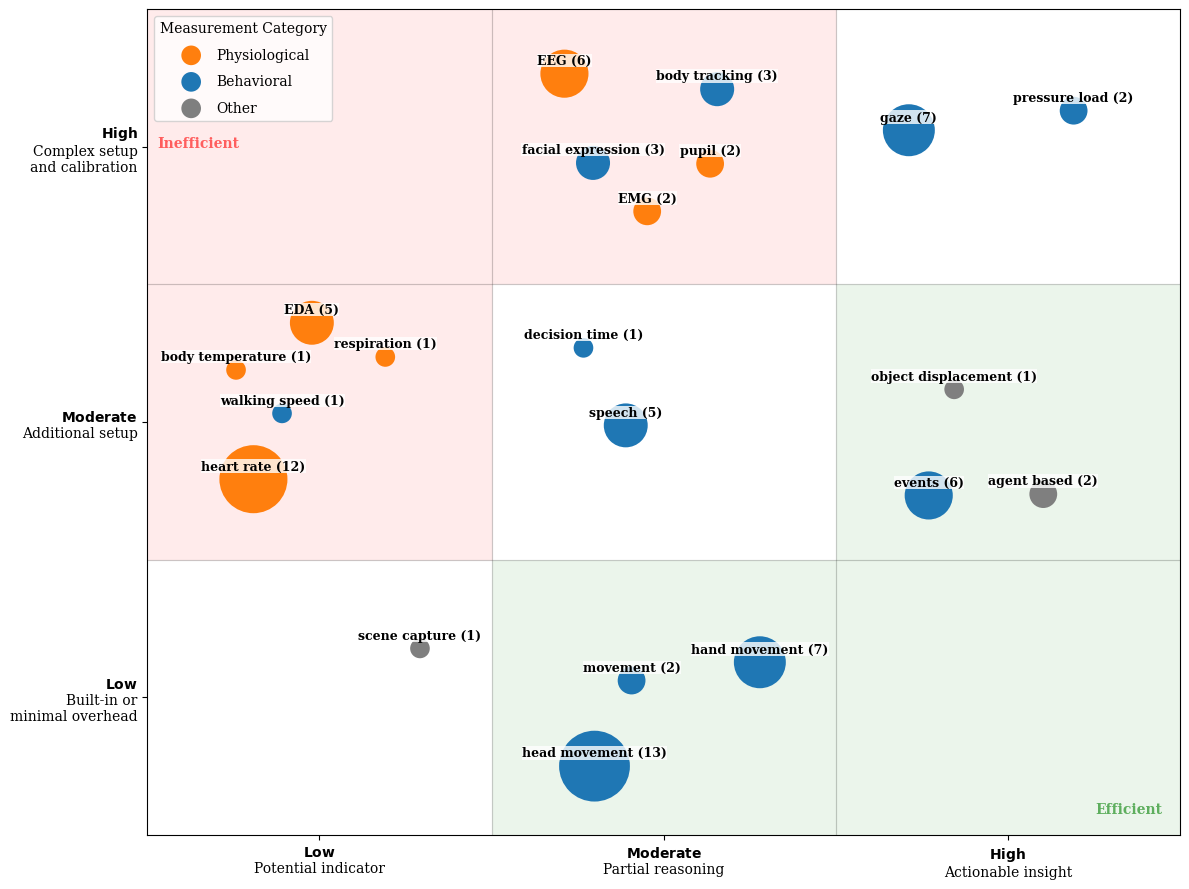

In [32]:
cols = list(measurement_metadata.keys())
counts = pd.DataFrame()
counts = df[cols].sum().reset_index()
counts.columns = ['measurement', 'count']
counts['type'] = counts['measurement'].map(lambda x: measurement_metadata[x]['type'])
counts['cost'] = counts['measurement'].map(lambda x: measurement_metadata[x]['cost'])
counts['insight'] = counts['measurement'].map(lambda x: measurement_metadata[x]['insight'])

new_rows_list = [
    {'measurement': 'agent based', 'count': 2, 'type': 'Other', 'cost': 2, 'insight': 3.2},
    {'measurement': 'object displacement', 'count': 1, 'type': 'Other', 'cost': 2.2, 'insight': 3}
]
new_rows_df = pd.DataFrame(new_rows_list)

counts = pd.concat([counts, new_rows_df], ignore_index=True)

fig,ax =plt.subplots(figsize=(12, 9))
np.random.seed(11) # For consistent jitter

cell_colors = {
    (1, 3): 'red', (2, 3): 'red', (1, 2): 'red',    # Ineffizient (Oben links)
    (1, 1): 'white', (2, 2): 'white', (3, 3): 'white', # Neutral (Diagonale)
    (2, 1): 'green', (3, 1): 'green', (3, 2): 'green'  # Effizient (Unten rechts)
}

for (ix, iy), color in cell_colors.items():
    # Wir zeichnen ein Rechteck für jede Zelle
    # bounds: x_start, y_start, breite, höhe
    rect = Rectangle((ix - 0.5, iy - 0.5), 1, 1,
                     facecolor=color, alpha=0.08, edgecolor='black', lw=0.5, zorder=1)
    ax.add_patch(rect)

# Draw Matrix Grid Lines
for pos in [1.5, 2.5]:
    plt.axhline(pos, color='black', lw=1, alpha=0.1, zorder=1)
    plt.axvline(pos, color='black', lw=1, alpha=0.1, zorder=1)

# Plotting
for m_type, color in color_map.items():
    subset = counts[counts['type'] == m_type]
    if subset.empty: continue

    # Jittering to separate points in the same cell
    xj = subset['insight'] + np.random.uniform(-0.3, 0.3, len(subset))
    yj = subset['cost'] + np.random.uniform(-0.3, 0.3, len(subset))

    plt.scatter(xj, yj, s=subset['count'] * 200, # Size factor
                c=color, label=m_type, alpha=1,
                edgecolors='none', linewidth=1.5, zorder=3)

    # Add labels
    for i, row in subset.iterrows():
        name = row['measurement'].replace('measurement_', '').replace('_', ' ')#.title()
        name = name + " (" + str(row['count']) + ")"
        plt.annotate(name, (xj.iloc[list(subset.index).index(i)], yj.iloc[list(subset.index).index(i)]),
                     xytext=(0, 7), textcoords="offset points", ha='center', fontsize=9, fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.1), zorder=5)


y_labels = {1: r"$\bf{Low}$" + "\nBuilt-in or\nminimal overhead",
            2: r"$\bf{Moderate}$" + "\nAdditional setup",
            3: r"$\bf{High}$" + "\nComplex setup\nand calibration"}
x_labels = {1: r"$\bf{Low}$" + "\nPotential indicator",
            2: r"$\bf{Moderate}$" + "\nPartial reasoning",
            3: r"$\bf{High}$" + "\nActionable insight"}

plt.xticks(list(x_labels.keys()), list(x_labels.values()), ha='center')
plt.yticks(list(y_labels.keys()), list(y_labels.values()), ha='right')


lgnd = plt.legend(
    title="Measurement Category",
    loc='upper left',
    bbox_to_anchor=(0, 1),
    labelspacing=0.9,
    frameon=True,
    fontsize=10
)
handles = getattr(lgnd, 'legend_handles', None) or getattr(lgnd, 'legendHandles', [])
for handle in handles:
    handle.set_sizes([200])

plt.text(3.45, 0.58, "Efficient", color='green',
         fontweight='bold', ha='right', alpha=0.6)
plt.text(0.53, 3, "Inefficient", color='red',
         fontweight='bold', ha='left', alpha=0.6)

plt.xlim(0.5, 3.5)
plt.ylim(0.5, 3.5)
# plt.legend(title="Measurement Type", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [33]:
counts

,measurement,count,type,cost,insight
0,measurement_heart_rate,12,Physiological,1.800,1.00
1,measurement_EEG,6,Physiological,3.000,2.00
2,measurement_EDA,5,Physiological,2.150,1.00
3,measurement_pupil,2,Physiological,2.800,2.00
4,measurement_EMG,2,Physiological,3.000,2.00
5,measurement_respiration,1,Physiological,2.000,1.20
6,measurement_body_temperature,1,Physiological,1.975,1.05
7,measurement_head_movement,13,Behavioral,1.000,2.00
8,measurement_hand_movement,7,Behavioral,1.000,2.20
9,measurement_gaze,7,Behavioral,3.000,3.00


In [34]:

method_cols = [c for c in df.columns if c.startswith('method_')]
dimension_cols = [c for c in df.columns if c.startswith('dimension_')]
measurement_cols = [c for c in df.columns if c.startswith('measurement_')]

def get_active_labels(row, columns, prefix):
    """Returns a joined string of column names where value is 1, stripped of prefix."""
    active = [c.replace(prefix, '').replace('_', ' ').replace('general','')#.title()
              for c in columns if row[c] == 1]
    return ", ".join(active)

summary_df = pd.DataFrame()
# summary_df['Ref'] = "\\citeauthor{" + df['Citationkey'] + "}\\cite{" + df['Citationkey'] + "}"
summary_df['Ref'] = "\\cite{" + df['Citationkey'] + "}"

summary_df['Methods'] = df.apply(lambda r: get_active_labels(r, method_cols, 'method_'), axis=1)
summary_df['Dimensions'] = df.apply(lambda r: get_active_labels(r, dimension_cols, 'dimension_'), axis=1)
summary_df['Measurements'] = df.apply(lambda r: get_active_labels(r, measurement_cols, 'measurement_'), axis=1)

summary_df = summary_df.sort_values('Ref').reset_index(drop=True)


In [35]:
print(summary_df.to_latex(index=False))

\begin{tabular}{llll}
\toprule
Ref & Methods & Dimensions & Measurements \\
\midrule
\cite{andronasSeamlessCollaborationHumans2023} & automated measurement & physical effort & pressure load \\
\cite{bianFrameworkPhysiologicalIndicators2016} & automated measurement & flow & heart rate, EMG, respiration \\
\cite{biriczUserFriendlyVirtual2022} & automated measurement &  usability, physical effort & hand movement, head movement \\
\cite{bozgeyikliExploringHorizontallyFlipped2023} & automated measurement & attention, cognitive load & EEG \\
\cite{cannavoEvaluationTestbedLocomotion2021} & automated measurement & physical effort & heart rate \\
\cite{cheEventBasedUserExperience2019} & automated measurement & UX & heart rate, events \\
\cite{dickinsonVirtualRealityCrowd2019} & automated measurement, visualization & UX & movement \\
\cite{dollingerIfItsNot2023} & automated measurement & presence & heart rate \\
\cite{dzardanovaExploringImpactNonverbal2024} & automated measurement & presence, ar

# Usability Dimension to Matrix Cell

In [36]:
def get_dimensions_from_measures(colnames: list[str]) -> pd.DataFrame:
  dimension_cols = [c for c in df.columns if c.startswith('dimension_')]

  # Generate mapping
  specific_mapping = []

  for m_col in colnames:
      if m_col in df.columns:
          # Filter for studies where this measurement is active
          active_studies = df[df[m_col] == 1]

          # Identify dimensions used in these studies (where sum > 0)
          active_dims = active_studies[dimension_cols].sum()
          used_dims = active_dims[active_dims > 0].index.tolist()

          # Format strings for the table
          m_name = clean_label(m_col)
          d_list = [clean_label(d) for d in used_dims]

          specific_mapping.append({
              'Measurement Source': m_name,
              'Evaluated Usability Dimensions': ", ".join(d_list) if d_list else "None"
          })

  # Create and display the lookup table
  results_df = pd.DataFrame(specific_mapping)
  display(results_df)

In [38]:
low_low = [
    'measurement_scene_capture',
]

low_moderate = [
    'measurement_head_movement',
    'measurement_hand_movement',
    'measurement_movement'
]

moderate_low = [
    'measurement_EDA',
    'measurement_respiration',
    'measurement_body_temperature',
    'measurement_heart_rate',
    'measurement_walking_speed',
]

moderate_moderate= [
    'measurement_decision_time',
    'measurement_speech',
]

moderate_high = [
    'measurement_none',
    'measurement_events'
]

high_moderate = [
    'measurement_EEG',
    'measurement_body_tracking',
    'measurement_facial_expression',
    'measurement_EMG',
    'measurement_pupil',
]

high_high = [
    'measurement_gaze',
    'measurement_pressure_load',
]
